In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv")

In [2]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(60000, 785)

In [4]:
df.sample()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
11710,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


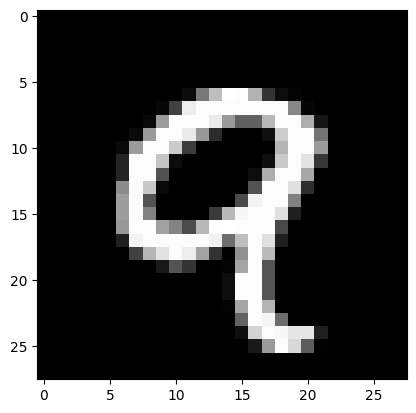

In [5]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[8358,1:].values.reshape(28,28),cmap='gray')

In [6]:
X = df.iloc[:, 1:] ## all rows and all columns except the first column
y = df.iloc[:, 0] ## all rows and only the first column

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [8]:
X_train.shape

(48000, 784)

In [9]:
y_train.shape

(48000,)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)   


KNeighborsClassifier()

In [11]:
import time

start = time.time()

y_pred = knn.predict(X_test)

print(time.time() - start)


23.2172794342041


In [12]:
from sklearn.metrics import accuracy_score 

accuracy_score(y_test, y_pred)

0.9715

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
### PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=100)

X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

In [15]:
X_train_scaled.shape

(48000, 100)

In [16]:
knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

0.96025

In [17]:
for i in range(1, 785):

    pca = PCA(n_components = i)
    X_train_scaled = pca.fit_transform(X_train)
    X_test_scaled = pca.fit_transform(X_test)

    knn = KNeighborsClassifier()

    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    print(accuracy_score(y_test, y_pred))

0.26866666666666666
0.41508333333333336
0.47733333333333333
0.6126666666666667
0.72525
0.52825
0.5706666666666667
0.6141666666666666
0.6293333333333333
0.66225
0.6870833333333334
0.7081666666666667
0.7366666666666667
0.747
0.75525
0.707
0.7204166666666667
0.7364166666666667
0.7456666666666667
0.7586666666666667
0.768
0.7720833333333333
0.7780833333333333
0.7876666666666666
0.7776666666666666
0.78175
0.7865
0.7916666666666666
0.7985833333333333
0.8020833333333334
0.80075


KeyboardInterrupt: 

In [18]:
### transforming to a 2S coordinate system

pca = PCA(n_components = 2)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)



In [19]:
X_train_trf

array([[ 233.7642094 ,  142.06416598],
       [ 511.02624798,   11.27761698],
       [-916.81173357,  722.00129818],
       ...,
       [1217.44442098,  427.47368978],
       [ 785.48139367, 1077.54868803],
       [-195.02923802, -375.65511632]], shape=(48000, 2))

In [20]:
!pip install plotly

In [21]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [22]:
## Transforming into 3D

pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test.trf = pca.transform(X_test)

/tmp/ipykernel_58/1147885106.py:5: UserWarning:

Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access



In [23]:
X_train_trf

array([[ 233.7642094 ,  142.06416598,  531.68751272],
       [ 511.02624798,   11.27761698, -244.27719352],
       [-916.81173357,  722.00129818, -319.13473937],
       ...,
       [1217.44442098,  427.47368978, -787.55678998],
       [ 785.48139367, 1077.54868803, -811.33311209],
       [-195.02923802, -375.65511632, -234.24664414]], shape=(48000, 3))

In [24]:
import plotly.express as px

y_train_trf = y_train.astype(str)

fig = px.scatter_3d(df,
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    z=X_train_trf[:, 2],
    color=y_train_trf
)

fig.update_layout(margin= dict(l=20, r=20, t=20, b=20))

fig.show()

In [25]:
pca.explained_variance_ ### eigen value

array([333975.90912692, 242665.73971384, 212615.23703541])

### Chossing optimal number of PCA

In [26]:


pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test.trf = pca.transform(X_test)

In [28]:
pca.explained_variance_.shape

(784,)

In [29]:
pca.components_.shape

(784, 784)

In [30]:
pca.explained_variance_ratio_

array([9.73277376e-02, 7.07179973e-02, 6.19606368e-02, 5.38583223e-02,
       4.86744921e-02, 4.31745862e-02, 3.27427545e-02, 2.88119480e-02,
       2.76442839e-02, 2.35732245e-02, 2.11183989e-02, 2.01102886e-02,
       1.71364653e-02, 1.69440924e-02, 1.58009538e-02, 1.48269684e-02,
       1.32641895e-02, 1.28431476e-02, 1.18502917e-02, 1.14671738e-02,
       1.06490249e-02, 1.00322587e-02, 9.49660963e-03, 9.14773535e-03,
       8.87652085e-03, 8.41251501e-03, 8.13264710e-03, 7.85679113e-03,
       7.44271212e-03, 6.87677255e-03, 6.57625999e-03, 6.44483547e-03,
       6.00968457e-03, 5.86090999e-03, 5.70949861e-03, 5.44347631e-03,
       5.07916573e-03, 4.86494715e-03, 4.81291836e-03, 4.73160204e-03,
       4.55622326e-03, 4.44708520e-03, 4.20170828e-03, 3.99550169e-03,
       3.84045879e-03, 3.74137318e-03, 3.62571862e-03, 3.53100295e-03,
       3.38635383e-03, 3.21574349e-03, 3.19858000e-03, 3.12791640e-03,
       2.98259662e-03, 2.88307788e-03, 2.84987116e-03, 2.71072381e-03,
      

In [31]:
### applying cumulative sum

import numpy as np

np.cumsum(pca.explained_variance_ratio_)

array([0.09732774, 0.16804573, 0.23000637, 0.28386469, 0.33253919,
       0.37571377, 0.40845653, 0.43726847, 0.46491276, 0.48848598,
       0.50960438, 0.52971467, 0.54685114, 0.56379523, 0.57959618,
       0.59442315, 0.60768734, 0.62053049, 0.63238078, 0.64384795,
       0.65449698, 0.66452924, 0.67402585, 0.68317358, 0.6920501 ,
       0.70046262, 0.70859526, 0.71645206, 0.72389477, 0.73077154,
       0.7373478 , 0.74379264, 0.74980232, 0.75566323, 0.76137273,
       0.76681621, 0.77189537, 0.77676032, 0.78157324, 0.78630484,
       0.79086106, 0.79530815, 0.79950986, 0.80350536, 0.80734582,
       0.81108719, 0.81471291, 0.81824391, 0.82163026, 0.82484601,
       0.82804459, 0.8311725 , 0.8341551 , 0.83703818, 0.83988805,
       0.84259877, 0.84529062, 0.84786264, 0.85039473, 0.85284853,
       0.85524569, 0.85763069, 0.85993453, 0.86215267, 0.86428997,
       0.86636194, 0.86839751, 0.87036118, 0.87228468, 0.87416878,
       0.8760432 , 0.87784795, 0.8796174 , 0.88135219, 0.88300

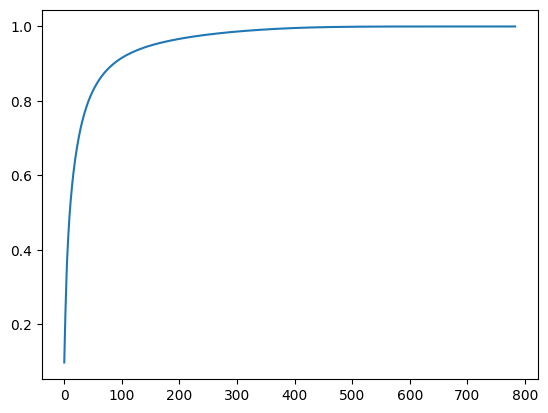

In [32]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))